In [1]:
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [2]:
import torch
torch.__version__

'2.9.0+cpu'

In [3]:
!pip install gpytorch
!pip install botorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.8/287.8 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.3/176.3 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 50.6 MB/s eta 0:00:00


In [4]:
import torch
import math
import gpytorch
import botorch
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
from matplotlib import cm
from gpytorch.kernels import MaternKernel, ScaleKernel, RBFKernel, LinearKernel, PeriodicKernel
from botorch.acquisition import ExpectedImprovement, UpperConfidenceBound, PosteriorMean
from botorch.optim import optimize_acqf
from botorch.sampling import SobolQMCNormalSampler
from gpytorch.constraints.constraints import Interval
from gpytorch.likelihoods.gaussian_likelihood import GaussianLikelihood
from gpytorch.constraints import GreaterThan
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.models.transforms.input import Normalize
from botorch.optim import optimize_acqf
plt.rcParams.update({'font.size':14})

# turn off warnings for clean output
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Helper function that takes input data, kernel+likelihood specifications, and plotting options --> return trained model
def get_trained_GP(X, Y, kernel_type, noise_free=False, plot_1d=False, plot_bounds=None):
    """
    This function is used to train a GP model based on the type of kernel that you select.
    This function will be used in modules 1,2,and 3. Save this function for later
    If you delete this cell accidentally, let us know!

    -----------
    Arg:
    X: Features/ Input vector -- torch tensor
    Y: Mapping/ Target variable vector -- torch tensor
    kernel_type: 'RBF'/'Linear'/'Periodic'/'Matern05'/'Matern15'/'Matern25' select one -- str
    noise_free: True or False (are observations noise free?)
    plot_1d: True or False (should we plot or not?)
    plot_bounds: Tuple of lower and upper bounds (xL, xU)

    ----------
    returns:

    model: a GP model object in train mode -- gpytorch
    """

    # make sure input data is shaped properly (ntrain by ninputs)
    if X.ndim != 2:
        raise ValueError(f"X must be 2D (n_train x n_inputs), got shape {X.shape}")

    if X.shape[-1]!=2:
        raise ValueError(f"Expected exactly 2 inputs (Polymer_thickness_mm, PCL_ratio), got {X.shape[-1]}")


    # make sure training data has the right dimension
    if Y.ndim == 1:
        Y = Y.unsqueeze(-1)
    elif Y.ndim!=2 or Y.shape[-1]!=1:
        raise ValueError(f"Y must be of shape (n,) or (n,1), got {Y.shape}")



    # output scaling
    standardize = Standardize(m=Y.shape[-1])
    outcome_transform = standardize

    # select covariance module
    input_dim = X.shape[-1]

    if kernel_type == 'RBF':
        covar_module = ScaleKernel(RBFKernel(ard_num_dims=input_dim))
    elif kernel_type == 'Linear':
        covar_module = ScaleKernel(LinearKernel(ard_num_dims=input_dim))
    elif kernel_type == 'Periodic':
        covar_module = ScaleKernel(PeriodicKernel(ard_num_dims=input_dim))
    elif kernel_type == 'Matern05':
        covar_module = ScaleKernel(MaternKernel(nu=0.5, ard_num_dims=input_dim))
    elif kernel_type == 'Matern15':
        covar_module = ScaleKernel(MaternKernel(nu=1.5, ard_num_dims=input_dim))
    elif kernel_type == 'Matern25':
        covar_module = ScaleKernel(MaternKernel(nu=2.5, ard_num_dims=input_dim))
    else:
        raise ValueError(f"Unknown kernel_type '{kernel_type}'")

    # set the likelihood
    if noise_free:
      likelihood = GaussianLikelihood(noise_constraint=Interval(lower_bound=1e-5, upper_bound=1e-3))
    else:
      likelihood = GaussianLikelihood(noise_constraint=Interval(lower_bound=1e-5, upper_bound=100))

    # define the model
    model = SingleTaskGP(
        train_X=X,
        train_Y=Y,
        covar_module=covar_module,
        likelihood=likelihood,
        outcome_transform=outcome_transform
    )

    # call the training procedure
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)

    # put in eval mode
    model.eval()

    # plot if specified
    if plot_1d:
      if input_dim == 1:
        if plot_bounds is None:
            print("Plot bounds not specified!")
        else:
          x_list = torch.linspace(plot_bounds[0], plot_bounds[1], 101)
          preds = model.posterior(x_list.unsqueeze(-1))
          mean = preds.mean.squeeze()
          var = preds.variance.squeeze()
          lcb = mean - 2*torch.sqrt(var)
          ucb = mean + 2*torch.sqrt(var)


          plt.figure(figsize=(12,10))
          plt.plot(x_list, mean.detach().numpy())
          plt.fill_between(
              x_list,
              lcb.detach().numpy(),
              ucb.detach().numpy(),
              alpha=0.2
          )
          plt.scatter(
              X.detach().numpy(),
              Y.detach().numpy(),
              color ='red',
              marker ='*'
          )
          plt.xlabel('input')
          plt.ylabel('target')
      else:
        print("Too many input dimensions to plot!")

    # return the trained model
    return model

In [6]:
def run_GP_and_Plot(df):
    # -----------------------------
    # 1. Fetching input and output
    # -----------------------------
    X_raw = torch.tensor(
        df[["Polymer_thickness_mm", "PCL_ratio"]].to_numpy(),
        dtype=torch.double,
    )
    Y_raw = torch.tensor(
        df["t_cross_days"].to_numpy(),
        dtype=torch.double,
    ).unsqueeze(-1)   # (n,1)

    # -----------------------------
    # 2. BO domain (outer bounds)
    # -----------------------------
    thickness_min = 0.001
    thickness_max = 0.09
    ratio_min = 0.01
    ratio_max = 1.0
    x_min = torch.tensor([thickness_min, ratio_min], dtype=torch.double)
    x_max = torch.tensor([thickness_max, ratio_max], dtype=torch.double)

    # scale inputs to [0,1]^3
    X_scaled = (X_raw - x_min) / (x_max - x_min)

    # -----------------------------
    # 3. Train GP on scaled X, negative Y
    # -----------------------------
    model = get_trained_GP(
        X_scaled,
        Y_raw,
        kernel_type="RBF",
        noise_free=False,
        plot_1d=False,
    )

    # make sure model is double
    model = model.to(torch.double)

    # -----------------------------
    # 4. EI object for BO and plotting
    # -----------------------------
    best_f = Y_raw.max().item()  # best (highest) t_cross_days
    ei = ExpectedImprovement(
        model=model,
        best_f=best_f,
        maximize=True,
    )

    # -----------------------------
    # 5. Optimize EI in scaled space to get next point
    # -----------------------------
    bounds_scaled = torch.stack(
        [
            torch.zeros(2, dtype=torch.double), #I changed this from 3 to 2
            torch.ones(2, dtype=torch.double),  #I changed this from 3 to 2
        ]
    )

    candidate, acq_value = optimize_acqf(
        acq_function=ei,
        bounds=bounds_scaled,
        q=1, # number of next input values to determine
        num_restarts=20,
        raw_samples=512,
    )

    x_next_scaled = candidate[0]              # shape (q, 2) where 2 is the number of input dimensions
    x_next = x_next_scaled * (x_max - x_min) + x_min   # back to physical space

    Polymer_thickness_mm_next = float(x_next[0].item())
    PCL_ratio_next    = float(x_next[1].item())
    ei_next     = float(acq_value.item())

    print("Suggested next input (unscaled):")
    print(f"  Polymer_thickness_mm = {Polymer_thickness_mm_next:.6g}")
    print(f"  PCL_ratio    = {PCL_ratio_next:.6g}")
    print(f"EI at this point = {ei_next:.6g}")

    # Scale new point to [0,1]^3
    x_new_scaled = (x_next - x_min) / (x_max - x_min)

    with torch.no_grad():
        post = model.posterior(x_new_scaled.unsqueeze(0))  # shape (1,3)
        pred_mean = post.mean.item()   # model predicts time in days to cross threshold
        std = post.variance.sqrt().item()

    print(f"\nGP-predicted time in days to cross the threshold at suggested point: {pred_mean:.6f}")
    print(f"GP uncertainty (std): {std:.6f}")

    bounds_dict = {
    "Polymer_thickness_mm": (thickness_min, thickness_max),
    "PCL_ratio": (ratio_min, ratio_max),
    }

    plot_gp_plus_ei_slice(
        "Polymer_thickness_mm",
        Polymer_thickness_mm_next, PCL_ratio_next,
        model, ei, bounds_dict, df,
        x_min, x_max,
    )

    plot_gp_plus_ei_slice(
        "PCL_ratio",
        Polymer_thickness_mm_next, PCL_ratio_next,
        model, ei, bounds_dict, df,
        x_min, x_max,
    )

    #Polymer_thickness_mm_star = Polymer_thickness_mm_next
    #PCL_ratio_star    = PCL_ratio_next

    #plot_ei_slice("Polymer_thickness_mm", Polymer_thickness_mm_star, PCL_ratio_star, bounds_dict)
    #plot_ei_slice("PCL_ratio",    Polymer_thickness_mm_star, PCL_ratio_star, bounds_dict)

    plot_gp_plus_ei_2d3d(model, ei, bounds_dict, df, x_min, x_max,
                       n_grid=100)


In [7]:
def plot_gp_plus_ei_slice(
    dim_name, Polymer_thickness_mm_val, PCL_ratio_val,
    model, ei_acq, bounds_dict, df,
    x_min, x_max,
):
    """
    dim_name : "Polymer_thickness_mm", "PCL_ratio"
    Polymer_thickness_mm_val, PCL_ratio_val: slice location in *physical* space
    model : GP trained on *scaled* inputs and t_cross_days
    ei_acq : ExpectedImprovement object
    bounds_dict : {"Polymer_thickness_mm": (Lmin,Lmax), "PCL_ratio_val":(...)} in physical space
    df : dataframe with columns ["Polymer_thickness_mm","PCL_ratio","t_cross_days"]
    x_min, x_max : tensors used for scaling (physical space)
    """

    # -----------------------
    # 1) Build physical grid for the slice
    # -----------------------
    lower, upper = bounds_dict[dim_name]

    grid_phys = torch.linspace(lower, upper, 200, dtype=torch.double)

    if dim_name == "Polymer_thickness_mm":
        Polymer_thickness_mm_phys = grid_phys
        PCL_ratio_phys = torch.full_like(grid_phys, PCL_ratio_val, dtype=torch.double)
        x_label = "Polymer_thickness_mm"

    elif dim_name == "PCL_ratio":
        Polymer_thickness_mm_phys = torch.full_like(grid_phys, Polymer_thickness_mm_val, dtype=torch.double)
        PCL_ratio_phys = grid_phys
        x_label = "PCL_ratio"

    Xtest_phys = torch.stack([Polymer_thickness_mm_phys, PCL_ratio_phys], dim=1)   # (N,2)

    # -----------------------
    # 2) Scale Xtest to [0,1]^3 for the GP
    # -----------------------
    Xtest_scaled = (Xtest_phys - x_min) / (x_max - x_min)
    Xtest_scaled = Xtest_scaled.to(torch.double)

    # -----------------------
    # 3) GP posterior (on t_cross_days)
    # -----------------------
    with torch.no_grad():
        post = model.posterior(Xtest_scaled)
        mean = post.mean.squeeze(-1).cpu().numpy()
        std = post.variance.sqrt().squeeze(-1).cpu().numpy()
        print("STD range on this slice:", std.min(), std.max())

    # Convert back to t_cross_days
    lcb = mean - 2.0 * std
    ucb = mean + 2.0 * std

    # -----------------------
    # 4) EI values on this slice (use scaled X)
    # -----------------------
    with torch.no_grad():
        ei_vals = ei_acq(Xtest_scaled.unsqueeze(1)).squeeze(-1).cpu().numpy()

    # -----------------------
    # 5) Observed points projected to this axis
    # -----------------------
    dim_col = {"Polymer_thickness_mm": "Polymer_thickness_mm", "PCL_ratio": "PCL_ratio"}[dim_name]
    x_obs = df[dim_col].to_numpy()
    y_obs = df["t_cross_days"].to_numpy()

    # -----------------------
    # 6) Plot
    # -----------------------
    x_grid_np = grid_phys.cpu().numpy()

    fig, ax1 = plt.subplots(figsize=(9, 5))

    # GP CI band
    ax1.fill_between(x_grid_np, lcb, ucb, color="lightblue", alpha=0.3, label="95% CI")

    # GP mean
    ax1.plot(x_grid_np, mean, color="blue", linewidth=2, label="GP mean")

    # Observed data
    ax1.scatter(x_obs, y_obs, color="red", marker="x", s=50, label="Observed")

    ax1.set_xlabel(x_label)
    ax1.set_ylabel("t_cross_days")
    ax1.grid(True)

    # EI on twin axis
    ax2 = ax1.twinx()
    ax2.plot(x_grid_np, ei_vals, color="orange", linestyle="--", linewidth=2, label="EI")
    ax2.set_ylabel("EI", color="orange")

    # Legends
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.title(f"GP Posterior + EI Slice over {x_label}")

    plt.tight_layout()

    #if df[["phenotype"]].values[0][0]=="network":
      #  save_path=os.path.join(net_plt_path, f"GP_EI_over_{dim_name}.png")
    #else:
      #  save_path=os.path.join(sph_plt_path, f"GP_EI_over_{dim_name}.png")
    #plt.savefig(save_path, dpi=300, bbox_inches='tight')

    #print(f"Plot saved successfully at:\n{save_path}")

    plt.show()

In [8]:
def plot_ei_slice(dim, Polymer_thickness_mm_val, PCL_ratio_val, bounds_dict, n=200):
    #bounds_dict : {"Polymer_thickness_mm": (Lmin,Lmax), "PCL_ratio_val":(...)} in physical space

    th_min, th_max = bounds_dict["Polymer_thickness_mm"]
    pcl_min, pcl_max = bounds_dict["PCL_ratio"]

    # Build a grid along the selected dimension
    if dim == "Polymer_thickness_mm":
        grid = torch.linspace(th_min, th_max, n)
        Polymer_thickness_mm = grid
        PCL_ratio = torch.full_like(grid, PCL_ratio_val)
        xlabel = "Polymer_thickness_mm"

    elif dim == "PCL_ratio":
        grid = torch.linspace(pcl_min, pcl_max, n)
        Polymer_thickness_mm = torch.full_like(grid, Polymer_thickness_mm_val)
        PCL_ratio = grid
        xlabel = "PCL_ratio"

    # Scale inputs
    Xtest = torch.stack([Polymer_thickness_mm, PCL_ratio], dim=1).double()
    Xtest_scaled = (Xtest - x_min) / (x_max - x_min)

    from botorch.acquisition import ExpectedImprovement
    best_f = Y_raw.max().item()
    ei = ExpectedImprovement(model=model, best_f=best_f, maximize=True)

    with torch.no_grad():
        ei_vals = ei(Xtest_scaled.unsqueeze(1)).squeeze().numpy()

    plt.figure(figsize=(7,4))
    plt.plot(grid.numpy(), ei_vals, lw=2)
    plt.title(f"EI slice over {xlabel}")
    plt.xlabel(xlabel)
    plt.ylabel("EI")
    plt.grid(True)

    #if df[["phenotype"]].values[0][0]=="network":
       # save_path=os.path.join(net_plt_path, f"EI_slice_over_{dim}.png")
    #else:
      #  save_path=os.path.join(sph_plt_path, f"EI_slice_over_{dim}.png")
    #plt.savefig(save_path, dpi=300, bbox_inches='tight')

   # print(f"Plot saved successfully at:\n{save_path}")

    plt.show()


In [9]:
def plot_gp_plus_ei_2d3d(model, ei_acq, bounds_dict, df, x_min, x_max,
                       n_grid=100):
    """
    model: GP trained on scaled inputs, predicting t_cross_days
    ei_acq: ExpectedImprovement object
    bounds_dict: {"Polymer_thickness_mm": (Lmin,Lmax), "PCL_ratio": (Lmin,Lmax)}
    df: dataframe with columns ["Polymer_thickness_mm","PCL_ratio","t_cross_days"]
    x_min, x_max: tensors used for scaling
    """

    # -----------------------
    # 1) Build 2D physical grid
    # -----------------------
    th_min, th_max = bounds_dict["Polymer_thickness_mm"]
    pcl_min, pcl_max = bounds_dict["PCL_ratio"]

    th_grid = torch.linspace(th_min, th_max, n_grid, dtype=torch.double)
    pcl_grid = torch.linspace(pcl_min, pcl_max, n_grid, dtype=torch.double)

    TH, PCL = torch.meshgrid(th_grid, pcl_grid, indexing="ij")  # (n,n)

    X_phys = torch.stack([TH.reshape(-1), PCL.reshape(-1)], dim=1)  # (n^2, 2)

    # -----------------------
    # 2) Scale to GP input space
    # -----------------------
    X_scaled = (X_phys - x_min) / (x_max - x_min)
    X_scaled = X_scaled.to(torch.double)

    # -----------------------
    # 3) GP posterior
    # -----------------------
    with torch.no_grad():
        post = model.posterior(X_scaled)
        mean = post.mean.view(-1).cpu().numpy()
        std = post.variance.sqrt().view(-1).cpu().numpy()

    # -----------------------
    # 4) EI values
    # -----------------------
    with torch.no_grad():
        ei_vals = ei_acq(X_scaled.unsqueeze(1)).view(-1).cpu().numpy()

    # -----------------------
    # 5) Reshape for plotting
    # -----------------------
    mean_2d = mean.reshape(n_grid, n_grid)
    std_2d = std.reshape(n_grid, n_grid)
    ei_2d = ei_vals.reshape(n_grid, n_grid)

    # -----------------------
    # -----------------------
    # 6) Plot GP posterior mean
    # -----------------------
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    im0 = ax[0].imshow(
        mean_2d,
        origin="lower",
        extent=[pcl_min, pcl_max, th_min, th_max],
        aspect="auto",
        cmap="viridis",
    )
    ax[0].set_title("GP Posterior Mean (t_cross_days)")
    ax[0].set_xlabel("PCL_ratio")
    ax[0].set_ylabel("Polymer_thickness_mm")
    fig.colorbar(im0, ax=ax[0])

    # ----------------------------------------------------
    # Plot all observed points (red)
    # ----------------------------------------------------
    ax[0].scatter(
        df["PCL_ratio"],
        df["Polymer_thickness_mm"],
        c="red",
        s=40,
        marker="x",
        label="Observed"
    )

    # ----------------------------------------------------
    # NEW LOGIC: highlight based on t_cross_days
    # ----------------------------------------------------
    dataset_max = df["dataset"].max()

    # A palette with enough distinct colors
    color_list = ["cyan", "magenta", "white", "lime", "orange","black"]

    # We will collect legend handles manually
    legend_handles = []

    if dataset_max == 1:
        # Only one dataset → highlight the single highest t_cross_days
        idx = df["t_cross_days"].idxmax()
        df_high = df.loc[[idx]]

        h = ax[0].scatter(
            df_high["PCL_ratio"],
            df_high["Polymer_thickness_mm"],
            c="cyan",
            s=90,
            marker="x",
            linewidths=2.5,
            label="best after LHS"
        )
        legend_handles.append(h)

    else:
        # Multiple datasets → highlight the max t_cross_days within each dataset
        for ds_id in range(1, dataset_max + 1):
            df_sub = df[df["dataset"] == ds_id]
            if len(df_sub) == 0:
                continue

            idx = df_sub["t_cross_days"].idxmax()
            df_high = df.loc[[idx]]

            color = color_list[(ds_id - 1) % len(color_list)]

            # Labeling rule:
            if ds_id == 1:
                label = "best after LHS"
            else:
                label = f"GP design {ds_id - 1}"

            h = ax[0].scatter(
                df_high["PCL_ratio"],
                df_high["Polymer_thickness_mm"],
                c=color,
                s=90,
                marker="x",
                linewidths=2.5,
                label=label
            )
            legend_handles.append(h)

    # ----------------------------------------------------
    # Final legend: Observed + highlight labels
    # ----------------------------------------------------
    ax[0].legend(handles=[ax[0].collections[0]] + legend_handles)


    # -----------------------
    # 7) Plot EI
    # -----------------------
    im1 = ax[1].imshow(ei_2d, origin="lower",
                       extent=[pcl_min, pcl_max, th_min, th_max],
                       aspect="auto", cmap="inferno")
    ax[1].set_title("Expected Improvement")
    ax[1].set_xlabel("PCL_ratio")
    ax[1].set_ylabel("Polymer_thickness_mm")
    fig.colorbar(im1, ax=ax[1])

    # Overlay observed points
    ax[1].scatter(df["PCL_ratio"], df["Polymer_thickness_mm"],
                  c="cyan", s=40, marker="x")

    plt.tight_layout()
    plt.show()

    """
    TH, PCL: meshgrid tensors (n,n)
    mean_2d, std_2d: numpy arrays (n,n)
    """

    # 95% confidence interval surfaces
    lcb_2d = mean_2d - 2 * std_2d
    ucb_2d = mean_2d + 2 * std_2d

    # Convert to numpy for plotting
    TH_np = TH.cpu().numpy()
    PCL_np = PCL.cpu().numpy()

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Mean surface
    ax.plot_surface(
        PCL_np, TH_np, mean_2d,
        cmap="viridis", alpha=0.9, linewidth=0, antialiased=True
    )

    # Lower CI surface
    ax.plot_surface(
        PCL_np, TH_np, lcb_2d,
        color="blue", alpha=0.25, linewidth=0
    )

    # Upper CI surface
    ax.plot_surface(
        PCL_np, TH_np, ucb_2d,
        color="blue", alpha=0.25, linewidth=0
    )

    ax.set_xlabel("PCL_ratio")
    ax.set_ylabel("Polymer_thickness_mm")
    ax.set_zlabel("t_cross_days")
    ax.set_title("3D GP Posterior with 95% Confidence Surfaces")

    plt.tight_layout()
    plt.show()
    from mpl_toolkits.mplot3d import Axes3D

    """
    TH, PCL: meshgrid tensors (n,n)
    ei_2d: numpy array (n,n) of EI values
    """

    TH_np = TH.cpu().numpy()
    PCL_np = PCL.cpu().numpy()

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection="3d")

    # EI surface
    surf = ax.plot_surface(
        PCL_np, TH_np, ei_2d,
        cmap="inferno",
        linewidth=0,
        antialiased=True,
        alpha=0.9
    )

    ax.set_xlabel("PCL_ratio")
    ax.set_ylabel("Polymer_thickness_mm")
    ax.set_zlabel("Expected Improvement")
    ax.set_title("3D Expected Improvement Surface")

    fig.colorbar(surf, ax=ax, shrink=0.6)

    plt.tight_layout()
    plt.show()

In [10]:
base_path = os.path.join(os.getcwd())# replace it with path relative your data location
df_all=pd.read_csv(os.path.join(base_path, "DataSheetForBO.csv"))
df_all.head()
df_5 = df_all.loc[df_all["Salt_percentage"] == 5.0]
print(df_5.head())
print(df_5.shape[0])

print(df_5['t_cross_days'].max())

# New row data (after first suggested design)
new_row_data = {'Salt_percentage': 5, 'Polymer_thickness_mm': 0.013, 'PCL_ratio': 0.01, 't_cross_days': 221, 'dataset':2}
new_row_df = pd.DataFrame([new_row_data], index=[0])
# Concatenating
df_5 = pd.concat([df_5, new_row_df], ignore_index=True)

# New row data (after second suggested design)
new_row_data = {'Salt_percentage': 5, 'Polymer_thickness_mm': 0.014, 'PCL_ratio': 1, 't_cross_days': 214, 'dataset':3}
new_row_df = pd.DataFrame([new_row_data], index=[0])
# Concatenating
df_5 = pd.concat([df_5, new_row_df], ignore_index=True)

# New row data (after third suggested design)
new_row_data = {'Salt_percentage': 5, 'Polymer_thickness_mm': 0.013, 'PCL_ratio': 0.02, 't_cross_days': 220, 'dataset':4}
new_row_df = pd.DataFrame([new_row_data], index=[0])
# Concatenating
df_5 = pd.concat([df_5, new_row_df], ignore_index=True)

# New row data (after fourth suggested design)
new_row_data = {'Salt_percentage': 5, 'Polymer_thickness_mm': 0.014, 'PCL_ratio': 0.069, 't_cross_days': 223, 'dataset':5}
new_row_df = pd.DataFrame([new_row_data], index=[0])
# Concatenating
df_5 = pd.concat([df_5, new_row_df], ignore_index=True)

# New row data (after fifth suggested design)
new_row_data = {'Salt_percentage': 5, 'Polymer_thickness_mm': 0.013, 'PCL_ratio': 0.13, 't_cross_days': 216, 'dataset':6}
new_row_df = pd.DataFrame([new_row_data], index=[0])
# Concatenating
df_5 = pd.concat([df_5, new_row_df], ignore_index=True)

# New row data (after sixth suggested design)
new_row_data = {'Salt_percentage': 5, 'Polymer_thickness_mm': 0.015, 'PCL_ratio': 0.01, 't_cross_days': 220, 'dataset':7}
new_row_df = pd.DataFrame([new_row_data], index=[0])
# Concatenating
df_5 = pd.concat([df_5, new_row_df], ignore_index=True)

   Salt_percentage  R_core_mm  Polymer_thickness_mm  PCL_ratio  Chi_ratio  \
0              5.0     0.1665                0.0635     0.0500     0.9500   
1              5.0     0.2114                0.0186     0.7064     0.2936   
2              5.0     0.1594                0.0706     0.8557     0.1443   
3              5.0     0.1975                0.0325     0.5760     0.4240   
4              5.0     0.2150                0.0150     0.9500     0.0500   

          a         b         c         d  t_cross_days  dataset  
0  0.412983 -0.001172 -0.005274 -0.005258      0.000000        1  
1  1.590128 -0.002963 -0.016275 -0.028405    192.038401        1  
2  0.408224 -0.001218 -0.001515 -0.016210      0.000000        1  
3  0.916568 -0.001859 -0.009994 -0.011066      4.137023        1  
4  2.066897 -0.003750 -0.019521 -0.048441    221.699739        1  
10
221.699738878619


Suggested next input (unscaled):
  Polymer_thickness_mm = 0.001
  PCL_ratio    = 0.01
EI at this point = 2.96088

GP-predicted time in days to cross the threshold at suggested point: 155.253719
GP uncertainty (std): 55.377413
STD range on this slice: 0.2556082119040586 76.93415867018882


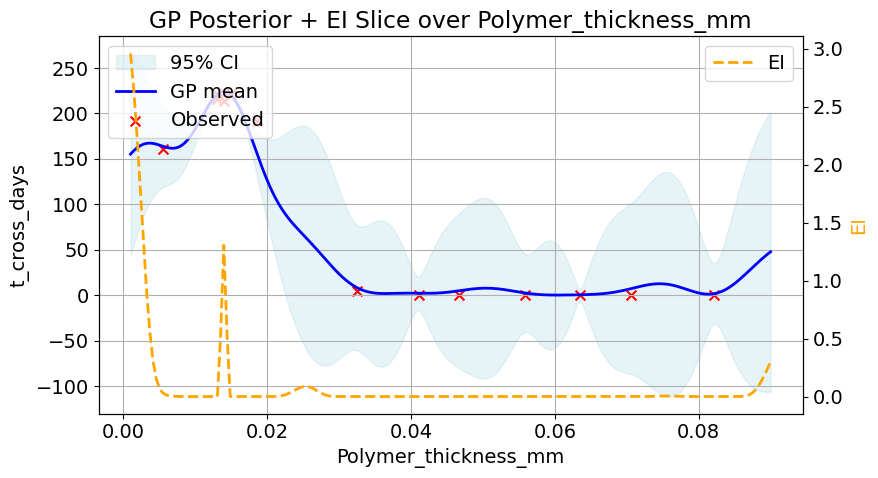

STD range on this slice: 50.65271509209891 56.36954655306358


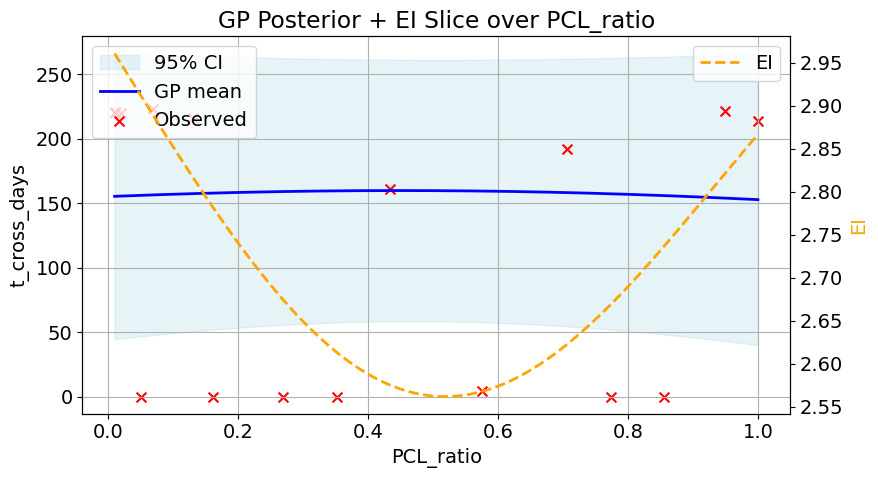

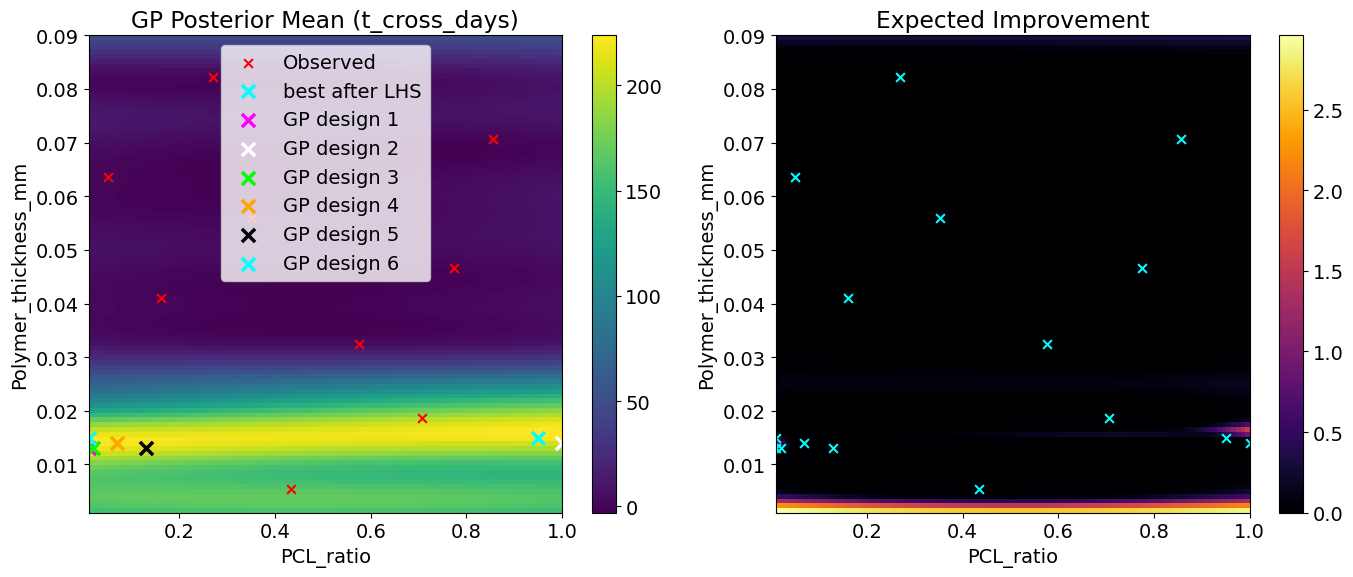

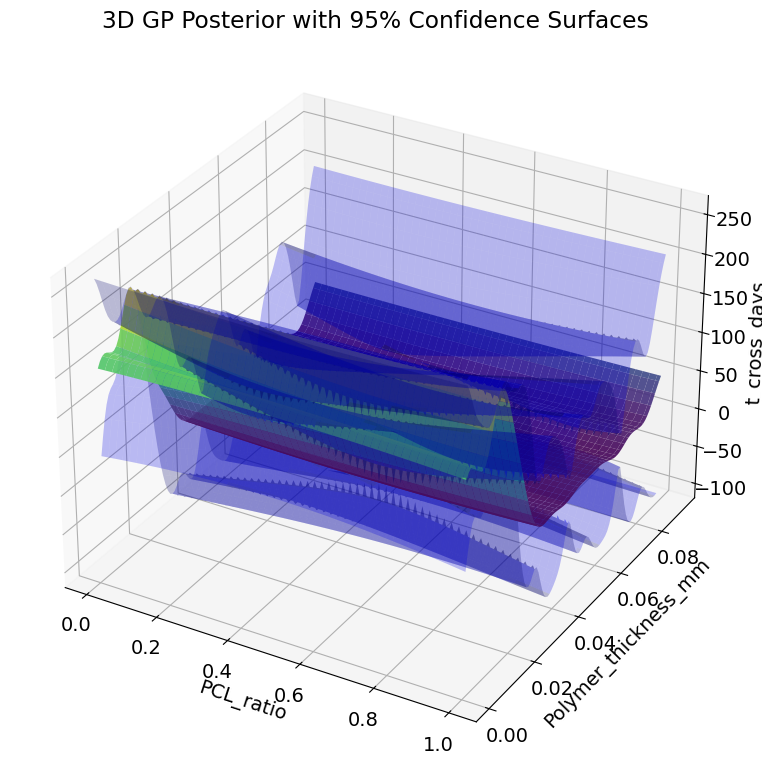

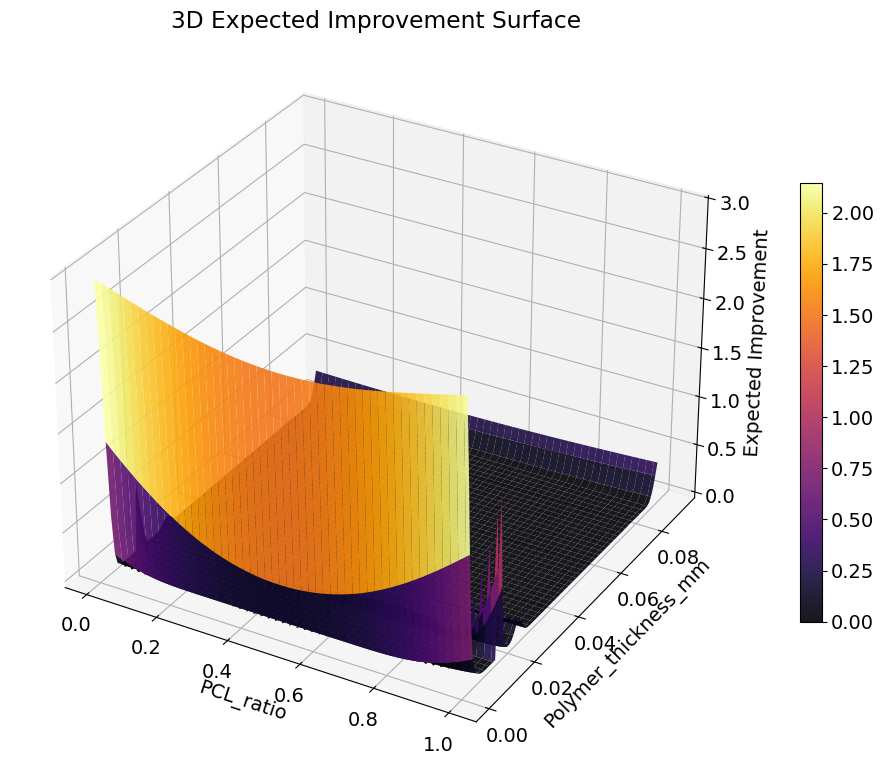

In [11]:
df = df_5
run_GP_and_Plot(df)

In [28]:
df_7pt5 = df_all.loc[df_all["Salt_percentage"] == 7.5]
print(df_7pt5.head())
print(df_7pt5.shape[0])
print(df_7pt5['t_cross_days'].max())

# # New row data (after first suggested design)
# new_row_data = {'Salt_percentage': 7.5, 'Polymer_thickness_mm': 0.011, 'PCL_ratio': 0.016, 't_cross_days': 171, 'dataset':2}
# new_row_df = pd.DataFrame([new_row_data], index=[0])
# # Concatenating
# df_7pt5 = pd.concat([df_7pt5, new_row_df], ignore_index=True)


# # New row data (after second suggested design)
# new_row_data = {'Salt_percentage': 7.5, 'Polymer_thickness_mm': 0.010, 'PCL_ratio': 0.053, 't_cross_days': 182, 'dataset':3}
# new_row_df = pd.DataFrame([new_row_data], index=[0])
# # Concatenating
# df_7pt5 = pd.concat([df_7pt5, new_row_df], ignore_index=True)

# # New row data (after third suggested design)
# new_row_data = {'Salt_percentage': 7.5, 'Polymer_thickness_mm': 0.013, 'PCL_ratio': 0.01, 't_cross_days': 119, 'dataset':4}
# new_row_df = pd.DataFrame([new_row_data], index=[0])
# # Concatenating
# df_7pt5 = pd.concat([df_7pt5, new_row_df], ignore_index=True)

# # New row data (after fourth suggested design)
# new_row_data = {'Salt_percentage': 7.5, 'Polymer_thickness_mm': 0.001, 'PCL_ratio': 1, 't_cross_days': 2, 'dataset':5}
# new_row_df = pd.DataFrame([new_row_data], index=[0])
# # Concatenating
# df_7pt5 = pd.concat([df_7pt5, new_row_df], ignore_index=True)

# # New row data (after fifth suggested design)
# new_row_data = {'Salt_percentage': 7.5, 'Polymer_thickness_mm': 0.0087, 'PCL_ratio': 1, 't_cross_days': 60, 'dataset':6}
# new_row_df = pd.DataFrame([new_row_data], index=[0])
# # Concatenating
# df_7pt5 = pd.concat([df_7pt5, new_row_df], ignore_index=True)

# # New row data (after sixth suggested design)
# new_row_data = {'Salt_percentage': 7.5, 'Polymer_thickness_mm': 0.013, 'PCL_ratio': 0.39, 't_cross_days': 145, 'dataset':7}
# new_row_df = pd.DataFrame([new_row_data], index=[0])
# # Concatenating
# df_7pt5 = pd.concat([df_7pt5, new_row_df], ignore_index=True)

# # New row data (after sixth suggested design)
# new_row_data = {'Salt_percentage': 7.5, 'Polymer_thickness_mm': 0.0077, 'PCL_ratio': 0.019, 't_cross_days': 192, 'dataset':8}
# new_row_df = pd.DataFrame([new_row_data], index=[0])
# # Concatenating
# df_7pt5 = pd.concat([df_7pt5, new_row_df], ignore_index=True)


    Salt_percentage  R_core_mm  Polymer_thickness_mm  PCL_ratio  Chi_ratio  \
10              7.5     0.1665                0.0635     0.0565     0.9435   
11              7.5     0.2114                0.0186     0.7064     0.2936   
12              7.5     0.1594                0.0706     0.8557     0.1443   
13              7.5     0.1975                0.0325     0.5760     0.4240   
14              7.5     0.2150                0.0150     0.9500     0.0500   

           a         b         c         d  t_cross_days  dataset  
10  0.242147 -0.000779  0.000000 -0.000779      0.000000        1  
11  1.566264 -0.003511 -0.027086 -0.023171    157.601684        1  
12  0.558047 -0.001861 -0.004878 -0.015903      0.000000        1  
13 -0.001413  0.005682  0.814502 -0.001710      0.000000        1  
14  2.415579 -0.007702 -0.088515 -0.070965    128.190604        1  
10
157.601683699381


Suggested next input (unscaled):
  Polymer_thickness_mm = 0.00819698
  PCL_ratio    = 0.0926263
EI at this point = 3.07976

GP-predicted time in days to cross the threshold at suggested point: 193.960970
GP uncertainty (std): 4.872770
STD range on this slice: 3.962823827576472 56.66892926825382


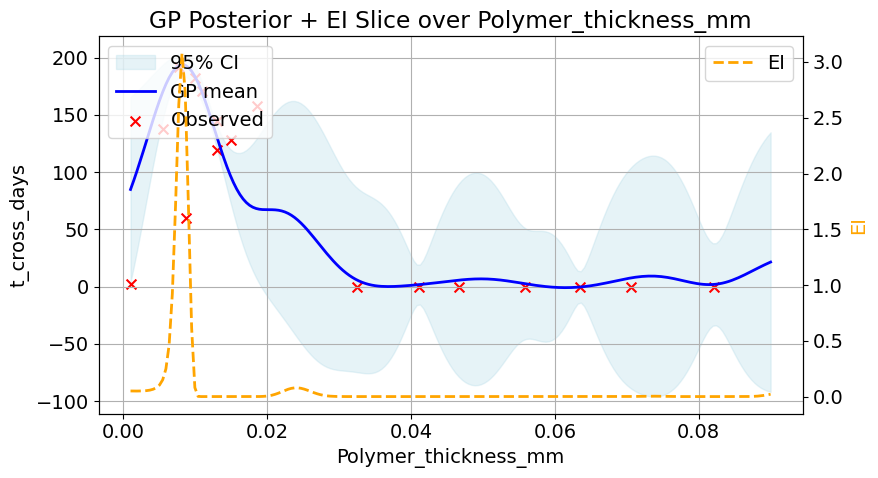

STD range on this slice: 4.523630211834104 11.355172156703793


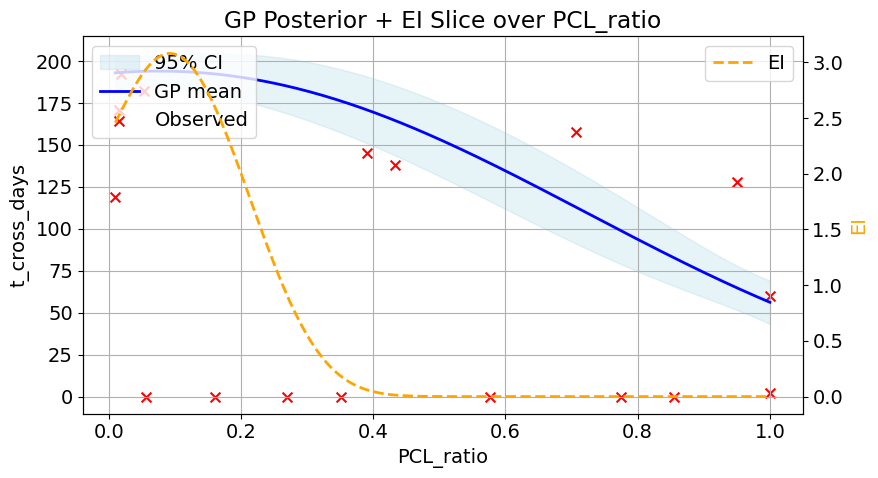

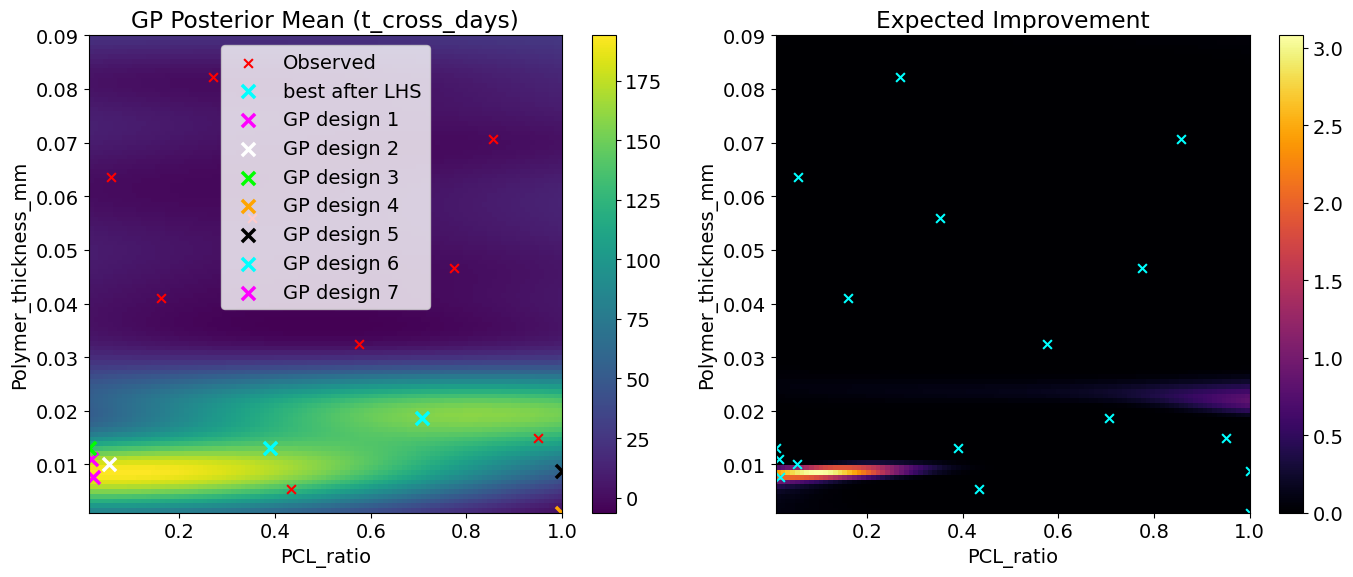

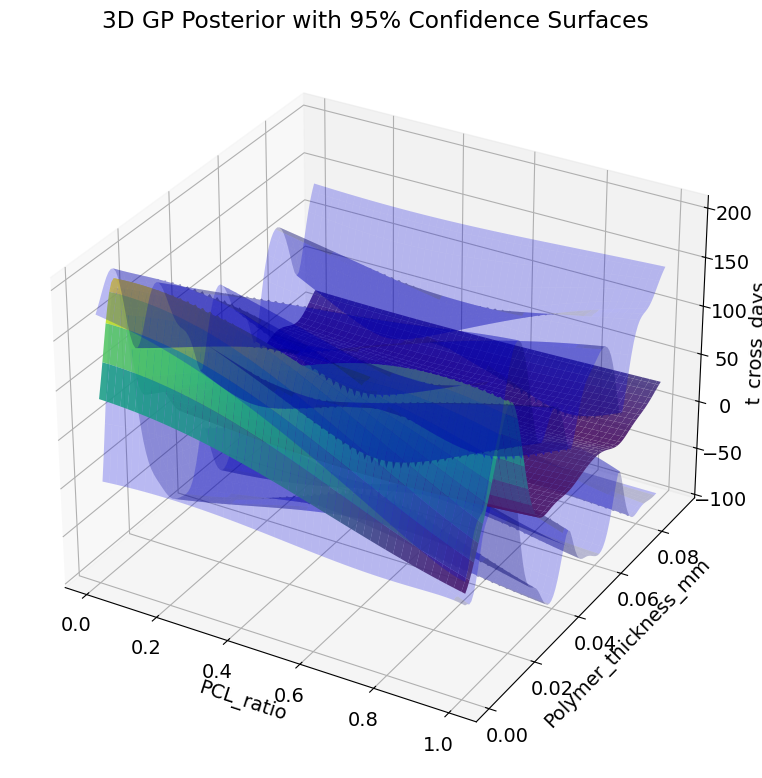

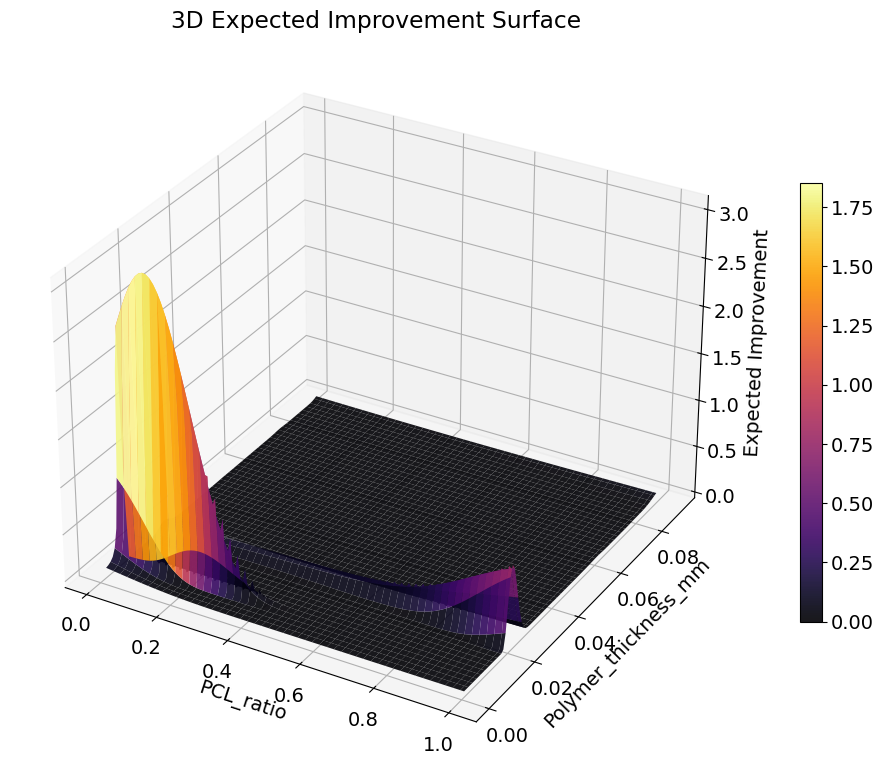

In [27]:
df = df_7pt5
run_GP_and_Plot(df)